In [4]:
!pip install speechbrain torchaudio


  Using cached speechbrain-1.0.3-py3-none-any.whl.metadata (24 kB)
  Using cached HyperPyYAML-1.2.2-py3-none-any.whl.metadata (7.6 kB)
  Using cached nvidia_cuda_nvrtc_cu12-12.4.127-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_runtime_cu12-12.4.127-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_cupti_cu12-12.4.127-py3-none-manylinux2014_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cudnn_cu12-9.1.0.70-py3-none-manylinux2014_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cublas_cu12-12.4.5.8-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cufft_cu12-11.2.1.3-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_curand_cu12-10.3.5.147-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cusolver_cu12-11.6.1.9-py3-none-manylinux2014_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cusparse_cu12-12.3.1.170-py3-none-manylinux2014_x86_64.whl.metadata

In [5]:
import os
import numpy as np
import torch
import torch.nn.functional as F
import torchaudio

from speechbrain.pretrained import EncoderClassifier
from sklearn.metrics import roc_curve
from collections import Counter

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

SAMPLE_RATE = 16000
EPSILONS = [0.0, 0.002, 0.005, 0.01, 0.02]


/tmp/ipykernel_47/3011667916.py:7: UserWarning: Module 'speechbrain.pretrained' was deprecated, redirecting to 'speechbrain.inference'. Please update your script. This is a change from SpeechBrain 1.0. See: https://github.com/speechbrain/speechbrain/releases/tag/v1.0.0
  from speechbrain.pretrained import EncoderClassifier


In [6]:
def load_timit_sa_recursive(root_dir):
    enroll, test = {}, {}
    for subdir, _, files in os.walk(root_dir):
        sa1_path, sa2_path = None, None
        for f in files:
            if f.upper().startswith("SA1") and f.lower().endswith(".wav"):
                sa1_path = os.path.join(subdir, f)
            elif f.upper().startswith("SA2") and f.lower().endswith(".wav"):
                sa2_path = os.path.join(subdir, f)

        if sa1_path and sa2_path:
            spk = os.path.basename(subdir)
            enroll_wav, _ = torchaudio.load(sa1_path)
            test_wav, _ = torchaudio.load(sa2_path)
            enroll[spk] = enroll_wav
            test[spk] = test_wav
    return enroll, test


TIMIT_ROOT = "/kaggle/input/timitcorpus/timit"
enroll, test = load_timit_sa_recursive(TIMIT_ROOT)

print("Enrollment speakers:", len(enroll))
print("Test speakers:", len(test))


Enrollment speakers: 16
Test speakers: 16


In [7]:
model_ecapa = EncoderClassifier.from_hparams(
    source="speechbrain/spkrec-ecapa-voxceleb",
    run_opts={"device": DEVICE}
)
model_ecapa.eval()


hyperparams.yaml: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.11/dist-packages/speechbrain/utils/autocast.py:188: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  wrapped_fwd = torch.cuda.amp.custom_fwd(fwd, cast_inputs=cast_inputs)


embedding_model.ckpt:   0%|          | 0.00/83.3M [00:00<?, ?B/s]

mean_var_norm_emb.ckpt:   0%|          | 0.00/1.92k [00:00<?, ?B/s]

classifier.ckpt:   0%|          | 0.00/5.53M [00:00<?, ?B/s]

label_encoder.txt: 0.00B [00:00, ?B/s]

EncoderClassifier(
  (mods): ModuleDict(
    (compute_features): Fbank(
      (compute_STFT): STFT()
      (compute_fbanks): Filterbank()
      (compute_deltas): Deltas()
      (context_window): ContextWindow()
    )
    (mean_var_norm): InputNormalization()
    (embedding_model): ECAPA_TDNN(
      (blocks): ModuleList(
        (0): TDNNBlock(
          (conv): Conv1d(
            (conv): Conv1d(80, 1024, kernel_size=(5,), stride=(1,))
          )
          (activation): ReLU()
          (norm): BatchNorm1d(
            (norm): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          )
          (dropout): Dropout1d(p=0.0, inplace=False)
        )
        (1): SERes2NetBlock(
          (tdnn1): TDNNBlock(
            (conv): Conv1d(
              (conv): Conv1d(1024, 1024, kernel_size=(1,), stride=(1,))
            )
            (activation): ReLU()
            (norm): BatchNorm1d(
              (norm): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affin

In [9]:
@torch.no_grad()
def ecapa_embedding(wav):
    """
    Input: wav tensor [1, N] or [N]
    Output: normalized embedding [192]
    """
    if wav.ndim == 1:
        wav = wav.unsqueeze(0)

    emb = model_ecapa.encode_batch(wav.to(DEVICE))  # [1, 192]
    emb = emb.squeeze(0)                             # [192]
    emb = F.normalize(emb, p=2, dim=-1)
    return emb


In [12]:
def compute_scores(enroll, test):
    scores, labels = [], []

    # Precompute enrollment embeddings
    enroll_emb = {spk: ecapa_embedding(enroll[spk]) for spk in enroll}

    for spk_te in test:
        emb_te = ecapa_embedding(test[spk_te])

        # ensure 1D
        emb_te = emb_te.view(-1)

        for spk_en in enroll:
            emb_en = enroll_emb[spk_en].view(-1)  # ensure 1D

            # cosine_similarity returns tensor([scalar]) → get scalar
            score = F.cosine_similarity(emb_te, emb_en, dim=0).item()
            scores.append(score)
            labels.append(1 if spk_te == spk_en else 0)

    return np.array(scores), np.array(labels)


In [13]:
def compute_eer(scores, labels):
    fpr, tpr, thresholds = roc_curve(labels, scores)
    fnr = 1 - tpr
    idx = np.nanargmin(np.abs(fpr - fnr))
    return (fpr[idx] + fnr[idx]) / 2
scores, labels = compute_scores(enroll, test)
eer = compute_eer(scores, labels)
print("Baseline TD-SV EER (ECAPA):", eer)


Baseline TD-SV EER (ECAPA): 0.0


In [16]:
def build_tdsv_trials(enroll, test):
    trials = []

    # Precompute enrollment embeddings
    enroll_emb = {spk: ecapa_embedding(enroll[spk]).view(-1) for spk in enroll}

    for spk_en in enroll:
        emb_en = enroll_emb[spk_en]

        for spk_te in test:
            emb_te = ecapa_embedding(test[spk_te]).view(-1)  # ensure 1D

            score = F.cosine_similarity(emb_te, emb_en, dim=0).item()

            same_speaker = (spk_en == spk_te)
            same_password = True  # SA1/SA2 fixed phrase

            if same_speaker and same_password:
                ttype, label = "TC", 1
            elif not same_speaker and same_password:
                ttype, label = "IC", 0
            else:
                continue

            trials.append({
                "score": score,
                "label": label,
                "type": ttype
            })

    return trials


In [17]:
trials = build_tdsv_trials(enroll, test)
print("Trial distribution:", Counter([t["type"] for t in trials]))

Trial distribution: Counter({'IC': 240, 'TC': 16})


In [18]:
def score_stats(trials):
    stats = {}
    for ttype in ["TC", "IC"]:
        vals = [t["score"] for t in trials if t["type"] == ttype]
        stats[ttype] = {
            "mean": np.mean(vals),
            "std": np.std(vals),
            "count": len(vals)
        }
    return stats

print(score_stats(trials))


{'TC': {'mean': 0.6672010738402605, 'std': 0.07910479124733409, 'count': 16}, 'IC': {'mean': 0.1078967999240073, 'std': 0.08505921087600742, 'count': 240}}


In [19]:
def fgsm_embedding_attack(emb_test, emb_target, epsilon):
    emb_adv = emb_test.clone().detach().requires_grad_(True)
    loss = -F.cosine_similarity(emb_adv, emb_target, dim=0)
    loss.backward()
    emb_adv = emb_adv + epsilon * emb_adv.grad.sign()
    return emb_adv.detach()


In [23]:
def compute_scores_adv(enroll, test, epsilon):
    scores, labels = [], []

    # Precompute enrollment embeddings as 1D
    enroll_emb = {spk: ecapa_embedding(enroll[spk]).view(-1) for spk in enroll}

    for spk_te in test:
        emb_te = ecapa_embedding(test[spk_te]).view(-1)   # ensure 1D
        target_emb = enroll_emb[spk_te]

        # Apply FGSM attack
        emb_adv = fgsm_embedding_attack(emb_te, target_emb, epsilon).view(-1)  # ensure 1D

        for spk_en in enroll:
            emb_en = enroll_emb[spk_en]
            score = F.cosine_similarity(emb_adv, emb_en, dim=0).item()  # now safe
            scores.append(score)
            labels.append(1 if spk_en == spk_te else 0)

    return np.array(scores), np.array(labels)


In [24]:
scores_clean, labels = compute_scores_adv(enroll, test, epsilon=0.0)
fpr, tpr, thresholds = roc_curve(labels, scores_clean)
fnr = 1 - tpr
tau = thresholds[np.nanargmin(np.abs(fpr - fnr))]

def compute_asr(scores_clean, scores_adv, labels, tau):
    success = ((scores_clean >= tau) & (scores_adv < tau))
    return success.sum() / len(scores_clean)

for eps in EPSILONS:
    scores_adv, _ = compute_scores_adv(enroll, test, eps)
    eer_adv = compute_eer(scores_adv, labels)
    asr = compute_asr(scores_clean, scores_adv, labels, tau)
    print(f"ε={eps:.3f} | EER={eer_adv:.4f} | ASR={asr:.2%}")


ε=0.000 | EER=0.0000 | ASR=0.00%
ε=0.002 | EER=0.0000 | ASR=0.39%
ε=0.005 | EER=0.0000 | ASR=0.78%
ε=0.010 | EER=0.0000 | ASR=0.78%
ε=0.020 | EER=0.0042 | ASR=2.73%


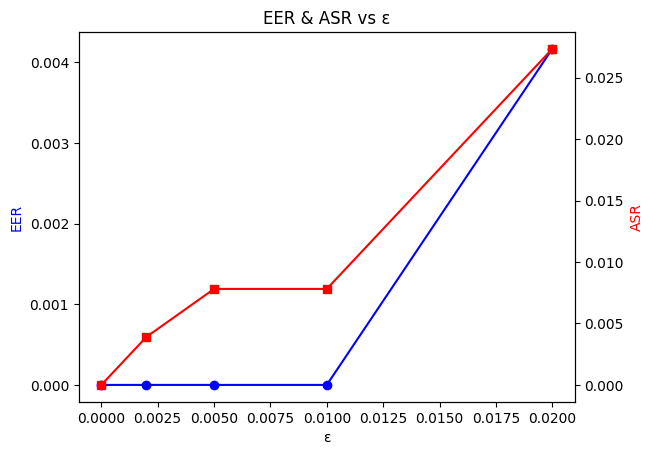

In [25]:
import matplotlib.pyplot as plt

eps_list, eer_list, asr_list = [], [], []
for eps in EPSILONS:
    scores_adv, _ = compute_scores_adv(enroll, test, eps)
    eer_adv = compute_eer(scores_adv, labels)
    asr = compute_asr(scores_clean, scores_adv, labels, tau)
    eps_list.append(eps)
    eer_list.append(eer_adv)
    asr_list.append(asr)

fig, ax1 = plt.subplots()
ax1.plot(eps_list, eer_list, 'b-o', label="EER")
ax1.set_xlabel("ε")
ax1.set_ylabel("EER", color='b')
ax2 = ax1.twinx()
ax2.plot(eps_list, asr_list, 'r-s', label="ASR")
ax2.set_ylabel("ASR", color='r')
plt.title("EER & ASR vs ε")
plt.show()